# Tutorial 16-2: The Critic's Advice – "Actor-Critic (A2C)"

**Course:** CSEN 342: Deep Learning  
**Topic:** Actor-Critic, Advantage Function, and Variance Reduction

## Objective
In REINFORCE (Tutorial 16-1), we saw that using the raw return $G_t$ leads to high variance gradients. The agent swings wildly between policies because it doesn't know what a "good" score is—it only knows the total sum.

**The Solution:** Use a **Baseline**. Instead of asking "Was the return high?", we ask "Was the return *higher than expected*?"

**Actor-Critic** combines two models:
1.  **The Actor (Policy $\pi$):** Decides which action to take.
2.  **The Critic (Value $V$):** Predicts how much reward we *should* get from state $s$.

The learning signal becomes the **Advantage**:
$$ A(s, a) = G_t - V(s) $$
If $A > 0$, the action was better than the Critic expected $\to$ Reinforce it!

In this tutorial, we will implement A2C (Advantage Actor-Critic) on CartPole.

---

## Part 1: The Dual-Head Network

Instead of two separate networks, we often use a single network with a shared body and two output heads. This allows the Actor and Critic to share feature representations.

In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import numpy as np
import matplotlib.pyplot as plt

# Config
env_name = "CartPole-v1"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
lr = 3e-4
gamma = 0.99

class ActorCritic(nn.Module):
    def __init__(self, state_size, action_size):
        super(ActorCritic, self).__init__()
        # Shared Feature Extractor
        self.fc1 = nn.Linear(state_size, 128)
        
        # Actor Head (Policy) -> Probabilities
        self.actor_fc = nn.Linear(128, action_size)
        
        # Critic Head (Value) -> Scalar V(s)
        self.critic_fc = nn.Linear(128, 1)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        
        # Actor: Softmax for probability distribution
        action_probs = F.softmax(self.actor_fc(x), dim=-1)
        
        # Critic: Linear output (estimate of total future reward)
        state_value = self.critic_fc(x)
        
        return action_probs, state_value

    def act(self, state):
        state_t = torch.from_numpy(state).float().to(device)
        probs, _ = self.forward(state_t)
        
        m = Categorical(probs)
        action = m.sample()
        
        return action.item(), m.log_prob(action)

env = gym.make(env_name)
model = ActorCritic(env.observation_space.shape[0], env.action_space.n).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

print("Actor-Critic Model Initialized.")

Actor-Critic Model Initialized.


---

## Part 2: The Training Loop (A2C Logic)

We calculate the losses directly inside the episode loop (or at the end of the episode).

**The Losses:**
1.  **Advantage:** $A_t = G_t - V(s_t)$. This is the error signal.
2.  **Critic Loss:** Minimize $A_t^2$ (MSE). We want $V(s_t)$ to accurately predict $G_t$.
3.  **Actor Loss:** $-\ln \pi(a_t|s_t) \times A_t$. We want to increase probability if Advantage is positive.
4.  **Entropy:** $- \sum p \log p$. We subtract this (maximize entropy) to encourage exploration.

In [2]:
def train_a2c(num_episodes=500):
    scores = []
    
    for i in range(num_episodes):
        state, _ = env.reset()
        log_probs = []
        values = []
        rewards = []
        done = False
        
        # 1. Rollout Episode
        while not done:
            # Turn state to tensor
            state_t = torch.from_numpy(state).float().to(device)
            
            # Forward Pass
            # We need V(s) for the Critic loss
            probs, value = model(state_t)
            
            # Sample Action
            m = Categorical(probs)
            action = m.sample()
            log_prob = m.log_prob(action)
            
            # Store for update
            log_probs.append(log_prob)
            values.append(value)
            
            # Step
            next_state, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated
            rewards.append(reward)
            state = next_state
            
        scores.append(sum(rewards))

        # 2. Calculate Returns (G_t)
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)
        returns = torch.tensor(returns).float().to(device)
        
        # Stack lists
        log_probs = torch.stack(log_probs)
        values = torch.stack(values).squeeze()
        
        # 3. Compute Advantage
        # A = G - V(s)
        # Detach G so we don't backprop into the future rewards (they are constants here)
        advantage = returns - values
        
        # 4. Compute Losses
        # Actor Loss: -log_prob * Advantage (Treat Advantage as constant for Actor)
        actor_loss = -(log_probs * advantage.detach()).mean()
        
        # Critic Loss: MSE(V(s), G)
        critic_loss = advantage.pow(2).mean()
        
        # Total Loss
        loss = actor_loss + 0.5 * critic_loss
        
        # 5. Update
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        if i % 50 == 0:
            print(f"Episode {i}\tScore: {np.mean(scores[-50:]):.2f}")
            
        if np.mean(scores[-10:]) > 195:
            print(f"Solved at episode {i}!")
            break
            
    return scores

print("Starting A2C Training...")
scores = train_a2c(num_episodes=2000)

Starting A2C Training...
Episode 0	Score: 38.00
Episode 50	Score: 28.10
Episode 100	Score: 25.34
Episode 150	Score: 24.70
Episode 200	Score: 32.10
Episode 250	Score: 31.14
Episode 300	Score: 37.74
Episode 350	Score: 38.80
Episode 400	Score: 47.88
Episode 450	Score: 51.98
Episode 500	Score: 55.70
Episode 550	Score: 60.12
Episode 600	Score: 58.88
Episode 650	Score: 64.06
Episode 700	Score: 65.12
Episode 750	Score: 78.66
Episode 800	Score: 90.08
Episode 850	Score: 80.34
Episode 900	Score: 97.18
Episode 950	Score: 126.28
Solved at episode 989!


---

## Part 3: Visualization & Analysis

Let's look at the learning curve. We expect A2C to be smoother than REINFORCE.

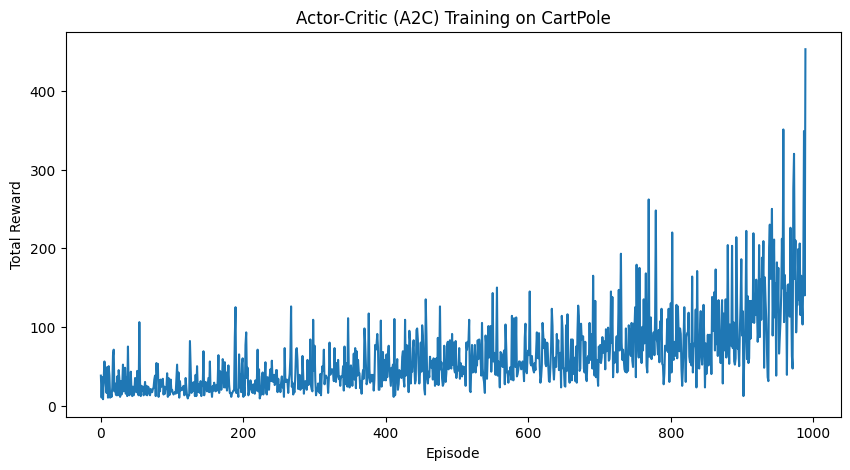

In [3]:
plt.figure(figsize=(10, 5))
plt.plot(scores)
plt.title("Actor-Critic (A2C) Training on CartPole")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.show()

And now let's see the outcome of this model.

In [4]:
import os
import matplotlib.animation as animation
from IPython.display import HTML

# Create a dummy runtime directory to satisfy the XDG requirement for remote servers
os.environ['XDG_RUNTIME_DIR'] = '/tmp/runtime-root'
if not os.path.exists(os.environ['XDG_RUNTIME_DIR']):
    os.makedirs(os.environ['XDG_RUNTIME_DIR'], exist_ok=True)

# Use 'agg' backend for matplotlib to avoid GUI dependency
import matplotlib
matplotlib.use('Agg')

def visualize_simulation(env_name, actor_critic_model, device, max_steps=500):
    # Re-create environment for rendering
    test_env = gym.make(env_name, render_mode="rgb_array")
    state, _ = test_env.reset()
    frames = []
    done = False
    steps = 0
    
    print("Simulating trained policy...")
    while not done and steps < max_steps:
        # Capture frame
        frames.append(test_env.render())
        
        # Select action using the trained model
        with torch.no_grad():
            # Use the 'act' method defined in your ActorCritic class
            action, _ = actor_critic_model.act(state)
            
        state, reward, terminated, truncated, _ = test_env.step(action)
        done = terminated or truncated
        steps += 1
    
    test_env.close()
    print(f"Simulation finished after {steps} steps.")
    
    # Create Animation
    fig = plt.figure(figsize=(6, 4))
    plt.axis('off')
    patch = plt.imshow(frames[0])

    def animate(i):
        patch.set_data(frames[i])
        return [patch]

    anim = animation.FuncAnimation(fig, animate, frames=len(frames), interval=50, blit=True)
    plt.close() 
    return HTML(anim.to_jshtml())

# Use 'model' as the second argument, which is the variable name used in Part 1
visualize_simulation("CartPole-v1", model, device)

Simulating trained policy...
Simulation finished after 134 steps.


### Discussion

**Why is the Advantage better than the Return?**

Imagine you get a score of +10 on a test. Is that good?
* If the class average (Baseline/Critic) is 5, then +10 is amazing! Advantage = +5.
* If the class average is 95, then +10 is terrible. Advantage = -85.

By subtracting the baseline, the Actor gets a much clearer signal about whether its specific action *helped* or *hurt*, reducing the noise in the gradient updates.

**Next Steps:**
While A2C is great, it can still suffer if the update step is too large (destroying the policy). The state-of-the-art solution is **PPO (Proximal Policy Optimization)**, which clips the update to ensure safe learning.